# Pachner-Move Simplification via RL -- Ver3 (100-tet benchmark)

This is a from-the-ground-up fix of every problem diagnosed in the first
attempt (Ver1). Three real issues were found and fixed:

1. **A ground-truth bug.** Ver1 computed "true minimum" by parsing
   `identify()` strings like `"m003(-2,3)"` and discarding the filling
   coefficients, loading the *unfilled, unrelated* cusped parent manifold
   instead of the actual closed target. This silently invalidated every
   "true minimum" comparison in Ver1's report (it claimed a gap like
   9 vs. 2, when the real best-known value is 9 vs. 9). Fixed in
   `ground_truth.py`, with the bug demonstrated directly below.

2. **Reward discounting was too aggressive, and exploration was
   distribution-shifted.** Ver1 used `gamma=0.9` (a 5-move delayed payoff
   loses 41% of its value) and trained *only* on synthetic scrambles of
   abstract minimal manifolds, which turned out not to resemble real
   Dehn-filled triangulations closely enough to transfer. Fixed with
   `gamma=0.97`, a lower step cost, and -- the main fix -- a **mixed
   curriculum** that trains directly on real, augmented Dehn-filled
   triangulations (11 training instances from 6 source manifolds: five knots plus the census manifold `m006`), not just
   synthetic scrambles.

3. **A biased exploration policy.** Uniform-random action sampling was
   heavily biased toward growing (2-3) moves simply because they
   outnumber shrinking (3-2) moves in the action list. Fixed with a
   single tunable `biased_choice` function, used two ways: biased toward
   shrinking during RL exploration, and biased toward growing when
   generating scrambles.

This notebook also adds what was requested as follow-up work: a properly
**statistical** evaluation (N=10 trials, mean +/- std, not single
trajectories) and a **local-minimum sanity test** comparing greedy vs. RL
head-to-head from a starting point already confirmed stuck under 250
restarts of SnapPy's own simplifier.

**Honest headline result, up front:** the ground-truth and training-
distribution fixes are real corrections, and real instances are now in
the training pool (Part 6). But on held-out instances
Ver2's RL agent is at parity with greedy -- no measurable edge in
either direction, in Part 7 or in the local-minimum sanity test
(Part 8) -- which is also where Ver1's RL ended up. The evaluation is
small (N=10), unpaired, and several instances have little or no
headroom, so it has little power to detect a difference either way.
See the conclusions at the end for the caveats, including a caveat
about the greedy baseline, and what's next.


## Setup

Requires `snappy`, `numpy`, `matplotlib`, `scikit-learn`.

**Files that must sit alongside this notebook:** `ver2_checkpoint.pkl`
(the trained 900-episode agent) and `pachner_agent_shim.py` (a small
compatibility file letting Python's pickle format find the `PachnerQAgent`
class under the module name it was originally trained under -- not used
for anything else; this notebook defines and trains its own identical
copy of the class).


In [1]:

import math, os, pickle, random, re, time, sys, types
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import snappy
from snappy.snap import t3mlite as t3m
from snappy.snap.t3mlite import Mcomplex
from sklearn.neural_network import MLPRegressor

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 10.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
})

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
print("SnapPy version:", snappy.__version__)


SnapPy version: 3.3.2


## Part 1 -- The Ground-Truth Bug, Demonstrated

`identify()` on a closed, Dehn-filled manifold returns a string like
`"[m003(-2,3)]"`: the manifold is isometric to the census (cusped) parent
`m003`, filled at slope `(-2,3)`. Ver1's parser threw the `(-2,3)` away.


In [2]:

# the exact Ver1 bug, reproduced
M = snappy.Manifold('4_1')
N = M.copy(); N.dehn_fill((5, 1))
idstr = str(N.identify())
print('identify() string:', idstr)

wrong_name = idstr.strip('[]').split('(')[0]
wrong_value = snappy.Manifold(wrong_name).num_tetrahedra()
print(f"Ver1's bug: parses out '{wrong_name}', loads it UNFILLED -> {wrong_value} tetrahedra")
print("  (this is the cusped SISTER manifold of 4_1, a totally different object)")

# the fix: parse out the filling coefficients too, and apply them
def parse_identify(s):
    m = re.search(r'([A-Za-z]+\d+)\((-?\d+)\s*,\s*(-?\d+)\)', s)
    if not m:
        return None
    return m.group(1), (int(m.group(2)), int(m.group(3)))

name, fill = parse_identify(idstr)
Mp = snappy.Manifold(name)
Mp.dehn_fill(fill)
correct_value = Mp.filled_triangulation().num_tetrahedra()
print(f"Ver2's fix: parses out '{name}' filled at {fill} -> {correct_value} tetrahedra (freshly retriangulated)")


identify() string: [m003(-2,3)]
Ver1's bug: parses out 'm003', loads it UNFILLED -> 2 tetrahedra
  (this is the cusped SISTER manifold of 4_1, a totally different object)
Ver2's fix: parses out 'm003' filled at (-2, 3) -> 9 tetrahedra (freshly retriangulated)


We don't actually know a *true* minimum for most of these closed
manifolds -- computing it exactly is the hard, in-general-unsolved problem
this whole project is about. So Ver2 reports an honestly-labeled **best
known** value (best of many restarts of SnapPy's own simplifier, on the
correctly-filled and retriangulated manifold), never a fabricated "true
minimum".


In [3]:

def best_known_minimum(parent_name, fill_coeffs, n_restarts=100):
    M = snappy.Manifold(parent_name)
    M.dehn_fill(fill_coeffs)
    best = M.filled_triangulation().num_tetrahedra()
    for _ in range(n_restarts):
        T = M.filled_triangulation()
        T.randomize()
        T.simplify()
        best = min(best, T.num_tetrahedra())
    return best


def best_known_for_instance(knot_name, pq, n_restarts=100):
    M = snappy.Manifold(knot_name)
    N = M.copy(); N.dehn_fill(pq)
    idstr = str(N.identify())
    parsed = parse_identify(idstr)
    if parsed is not None:
        parent_name, parent_fill = parsed
        best = best_known_minimum(parent_name, parent_fill, n_restarts=n_restarts)
    else:
        best = N.filled_triangulation().num_tetrahedra()
        for _ in range(n_restarts):
            T = N.filled_triangulation()
            T.randomize()
            T.simplify()
            best = min(best, T.num_tetrahedra())
    return best, idstr


# corrected values for the four instances used throughout the project
for knot, pq in [('4_1', (5, 1)), ('5_2', (7, 1)), ('6_1', (5, 1)), ('6_3', (5, 1))]:
    best, idstr = best_known_for_instance(knot, pq, n_restarts=60)
    print(f"{knot}{pq}: identify={idstr}  corrected best_known={best}")


4_1(5, 1): identify=[m003(-2,3)]  corrected best_known=9
5_2(7, 1): identify=[m015(5,1)]  corrected best_known=10
6_1(5, 1): identify=[m032(7,1)]  corrected best_known=14
6_3(5, 1): identify=[s912(5,1)]  corrected best_known=15


## Part 2 -- The Pachner Move Environment

Unchanged from Ver1 and already verified there (real per-move control via
SnapPy's internal `t3mlite` library; move set `{2-3, 3-2, 4-4}`, since
these are one-vertex triangulations of closed manifolds and only 1-4/4-1
would change the vertex count). `STEP_COST` is lowered from 0.05 to 0.02
here to reduce the fixed tax on longer solution paths now that `gamma` is
higher (see Part 3).


In [4]:

STEP_COST = 0.02
MAX_VALENCE_BUCKET = 10


def build_mcomplex(snappy_triangulation):
    mc = Mcomplex(snappy_triangulation)
    mc.rebuild()
    return mc


def legal_actions(mc):
    actions = []
    seen_faces = set()
    for tet in mc.Tetrahedra:
        for F in t3m.TwoSubsimplices:
            face_obj = tet.Class[F]
            if face_obj.Index in seen_faces:
                continue
            seen_faces.add(face_obj.Index)
            if tet.Neighbor[F] is tet:
                continue
            actions.append(('2-3', tet, F))
    for e in mc.Edges:
        val = e.valence()
        if val == 3:
            actions.append(('3-2', e))
        elif val == 4:
            actions.append(('4-4', e))
    return actions


def _face_edge_valences(tet, F):
    verts_on_face = [v for v in (1, 2, 4, 8) if F & v]
    edge_masks = [F ^ v for v in verts_on_face]
    return [tet.Class[em].valence() for em in edge_masks]


def action_features(action):
    kind = action[0]
    is23 = float(kind == '2-3'); is32 = float(kind == '3-2'); is44 = float(kind == '4-4')
    if kind == '2-3':
        delta = 1.0; vals = _face_edge_valences(action[1], action[2])
    elif kind == '3-2':
        delta = -1.0; vals = [3]
    else:
        delta = 0.0; vals = [4]
    vmean = min(np.mean(vals), MAX_VALENCE_BUCKET) / MAX_VALENCE_BUCKET
    vmax = min(np.max(vals), MAX_VALENCE_BUCKET) / MAX_VALENCE_BUCKET
    return np.array([is23, is32, is44, delta / 3.0, vmean, vmax], dtype=np.float32)


def state_features(mc, start_count, steps_left, max_steps):
    n = len(mc.Tetrahedra)
    valences = [e.valence() for e in mc.Edges]
    m = max(len(valences), 1)
    frac_le3 = sum(v <= 3 for v in valences) / m
    frac_4 = sum(v == 4 for v in valences) / m
    frac_ge6 = sum(v >= 6 for v in valences) / m
    return np.array([n / start_count, steps_left / max_steps, frac_le3, frac_4,
                      frac_ge6, len(valences) / max(1, start_count)], dtype=np.float32)


class PachnerEnv:
    def __init__(self, snappy_triangulation, max_steps=40):
        self.mc = build_mcomplex(snappy_triangulation)
        self.start_count = len(self.mc.Tetrahedra)
        self.max_steps = max_steps
        self.steps = 0
        self.best_count = self.start_count

    def current_actions(self):
        return legal_actions(self.mc)

    def obs(self, actions=None):
        if actions is None:
            actions = self.current_actions()
        s = state_features(self.mc, self.start_count, self.max_steps - self.steps, self.max_steps)
        return s, actions

    def step(self, action):
        prev = len(self.mc.Tetrahedra)
        kind = action[0]
        try:
            if kind == '2-3':
                ok = self.mc.two_to_three(action[2], action[1], must_succeed=False)
            elif kind == '3-2':
                ok = self.mc.three_to_two(action[1].get_arrow(), must_succeed=False)
            else:
                ok = self.mc.four_to_four(action[1].get_arrow(), must_succeed=False)
        except Exception:
            ok = False
        if ok:
            self.mc.rebuild()
        new = len(self.mc.Tetrahedra)
        self.best_count = min(self.best_count, new)
        self.steps += 1
        reward = (prev - new) - STEP_COST if ok else -1.0
        done = (self.steps >= self.max_steps) or (new > 3 * self.start_count + 10)
        return reward, done, ok

    def tet_count(self):
        return len(self.mc.Tetrahedra)

    def to_snappy(self):
        return self.mc.snappy_manifold()


print('Environment defined.')


Environment defined.


## Part 3 -- The Ver2 Agent

`gamma` raised to 0.97. `biased_choice` replaces Ver1's flat-uniform
random sampling with a single tunable function used two ways: positive
`shrink_bias` favors shrinking (3-2) moves during RL exploration;
negative `shrink_bias` favors growing (2-3) moves when generating
scrambles/augmentations.


In [5]:

def biased_choice(actions, rng, shrink_bias=0.0):
    by_type = {}
    for i, a in enumerate(actions):
        by_type.setdefault(a[0], []).append(i)
    types = list(by_type.keys())
    weights = []
    for t in types:
        w = 1.0
        if t == '3-2':
            w *= max(0.02, 1.0 + shrink_bias)
        elif t == '2-3':
            w *= max(0.02, 1.0 - shrink_bias)
        weights.append(w)
    total = sum(weights)
    r = rng.random() * total
    cum = 0.0
    chosen_type = types[-1]
    for t, w in zip(types, weights):
        cum += w
        if r <= cum:
            chosen_type = t
            break
    return rng.choice(by_type[chosen_type])


class PachnerQAgent:
    def __init__(self, hidden=(64, 64), gamma=0.97, seed=0):
        self.gamma = gamma
        self.model = MLPRegressor(hidden_layer_sizes=hidden, activation="relu", solver="adam",
                                   learning_rate_init=1e-3, warm_start=True, max_iter=1, random_state=seed)
        self.fitted = False
        self.replay = []
        self.rng = random.Random(seed)

    def q_values(self, s_feat, action_feats):
        if not action_feats:
            return np.array([])
        X = np.stack([np.concatenate([s_feat, af]) for af in action_feats])
        if not self.fitted:
            return np.zeros(len(action_feats))
        return self.model.predict(X)

    def select(self, s_feat, actions, action_feats, epsilon, explore_shrink_bias=0.3):
        if not actions:
            return None
        if self.rng.random() < epsilon:
            return biased_choice(actions, self.rng, shrink_bias=explore_shrink_bias)
        qs = self.q_values(s_feat, action_feats)
        return int(np.argmax(qs))

    def remember(self, s, a_feat, r, s_next, next_action_feats, done):
        self.replay.append((s, a_feat, r, s_next, next_action_feats, done))
        if len(self.replay) > 40000:
            self.replay.pop(0)

    def train_batch(self, batch_size=256):
        if len(self.replay) < 32:
            return
        batch = self.rng.sample(self.replay, min(batch_size, len(self.replay)))
        X, y = [], []
        for s, a_feat, r, s_next, next_afs, done in batch:
            target = r
            if not done and next_afs:
                q_next = self.q_values(s_next, next_afs)
                target += self.gamma * float(np.max(q_next))
            X.append(np.concatenate([s, a_feat]))
            y.append(target)
        self.model.partial_fit(np.array(X), np.array(y))
        self.fitted = True


print('Agent defined.')


Agent defined.


## Part 4 -- Baselines


In [6]:

def reference_invariants(snappy_manifold):
    return float(snappy_manifold.volume()), str(snappy_manifold.identify())


def get_triangulation(name, pq, max_attempts=6):
    # SnapPy's own filled_triangulation() is itself flaky ~30-60% of the
    # time even at zero Pachner moves (a solver-conditioning quirk, not a
    # topology bug) -- retry for a cleanly-solving start.
    M = snappy.Manifold(name)
    N = M.copy(); N.dehn_fill(pq)
    orig_vol, orig_id = reference_invariants(N)
    for _ in range(max_attempts):
        T = N.filled_triangulation()
        mc = build_mcomplex(T)
        M0 = mc.snappy_manifold()
        if M0.solution_type() == "all tetrahedra positively oriented":
            return T, orig_vol, orig_id
    return T, orig_vol, orig_id


def greedy_simplify(triangulation, max_steps=60, rng=None):
    rng = rng or random.Random()
    env = PachnerEnv(triangulation, max_steps=max_steps)
    trace = [env.tet_count()]
    no_improve = 0
    for _ in range(max_steps):
        acts = env.current_actions()
        if not acts:
            break
        reducing = [a for a in acts if a[0] == "3-2"]
        a = rng.choice(reducing) if reducing else rng.choice(acts)
        no_improve = 0 if reducing else no_improve + 1
        env.step(a)
        trace.append(env.tet_count())
        if no_improve > 6:
            break
    return env, trace


def random_walk_simplify(triangulation, max_steps=60, seed=None, patience=None, shrink_bias=0.0):
    rng = random.Random(seed)
    env = PachnerEnv(triangulation, max_steps=max_steps)
    trace = [env.tet_count()]
    best_seen = env.tet_count()
    stall = 0
    for _ in range(max_steps):
        acts = env.current_actions()
        if not acts:
            break
        idx = biased_choice(acts, rng, shrink_bias=shrink_bias)
        _, done, ok = env.step(acts[idx])
        trace.append(env.tet_count())
        if ok and env.tet_count() < best_seen:
            best_seen = env.tet_count(); stall = 0
        else:
            stall += 1
        if patience and stall > patience:
            break
        if done:
            break
    return env, trace


def snappy_builtin_best_of(triangulation, n_restarts=10):
    best = triangulation.num_tetrahedra()
    best_T = triangulation
    for _ in range(n_restarts):
        T2 = triangulation.copy()
        T2.randomize(); T2.simplify()
        if T2.num_tetrahedra() < best:
            best = T2.num_tetrahedra(); best_T = T2
    return best_T, best


print('Baselines defined.')


Baselines defined.


## Part 5 -- Mixed Curriculum Training

This is the main structural fix. Ver1 trained only on random scrambles of
abstract known-minimal manifolds (m003, m015, m032, s912) -- it learned
that task well (94% success at shallow depth) but the skill did not
transfer to real Dehn-filled triangulations at all, because they turned
out not to resemble random scrambles closely enough.

Ver2 mixes in a second, larger source of training episodes: **real**
Dehn-filled triangulations from an 11-instance pool (6 source manifolds: five knots up to
6 crossings, plus the census manifold `m006`), optionally pushed a little further out with a few
growth-biased moves, with the target being that instance's own **best
known** value (honest and achievable, from Part 1's corrected ground
truth) rather than a fabricated exact minimum. Training mixes synthetic
and real episodes, shifting from mostly-synthetic (bootstrapping) early to
mostly-real by the end.

Training took roughly 35 minutes over 900 episodes in the original
sandbox (single CPU, tool-call time limits requiring checkpointed chunks).
**By default this notebook loads the trained checkpoint** rather than
re-running that.


In [7]:

TOTAL_EPISODES = 900
CHECKPOINT_PATH = "ver3_checkpoint.pkl"

SYNTHETIC_MANIFOLDS = ["m003", "m004", "m015", "m032", "s912"]
REAL_TRAIN_INSTANCES = [
    ("4_1", (5, 1)), ("4_1", (8, 1)), ("4_1", (9, 1)),
    ("5_2", (9, 1)), ("5_2", (11, 1)),
    ("6_1", (5, 1)), ("6_1", (9, 1)),
    ("6_2", (7, 1)),
    ("6_3", (5, 1)),
    ("m006", (5, 1)), ("m006", (7, 1)),
]
SYNTH_FRAC_START, SYNTH_FRAC_END = 0.7, 0.3
SCRAMBLE_SHRINK_BIAS = -0.6
SUCCESS_BONUS = 5.0
MIN_SYN_DEPTH, MAX_SYN_DEPTH = 2, 30
MIN_REAL_EXTRA, MAX_REAL_EXTRA = 0, 10


def curriculum_frac(ep):
    return min(1.0, ep / (0.7 * TOTAL_EPISODES))

def synth_max_depth(ep):
    f = curriculum_frac(ep)
    return int(round(MIN_SYN_DEPTH + f * (MAX_SYN_DEPTH - MIN_SYN_DEPTH)))

def real_max_extra(ep):
    f = curriculum_frac(ep)
    return int(round(MIN_REAL_EXTRA + f * (MAX_REAL_EXTRA - MIN_REAL_EXTRA)))

def synth_episode_probability(ep):
    f = curriculum_frac(ep)
    return SYNTH_FRAC_START + f * (SYNTH_FRAC_END - SYNTH_FRAC_START)


def _apply_moves(mc, n_moves, rng, shrink_bias):
    for _ in range(n_moves):
        acts = legal_actions(mc)
        if not acts:
            break
        idx = biased_choice(acts, rng, shrink_bias=shrink_bias)
        kind, *rest = acts[idx]
        try:
            if kind == '2-3':
                tet, F = rest
                mc.two_to_three(F, tet, must_succeed=False)
            elif kind == '3-2':
                (edge,) = rest
                mc.three_to_two(edge.get_arrow(), must_succeed=False)
            else:
                (edge,) = rest
                mc.four_to_four(edge.get_arrow(), must_succeed=False)
        except Exception:
            pass
        mc.rebuild()


def make_synthetic_env(name, n_scramble, max_steps, rng):
    M0 = snappy.Manifold(name)
    mc = build_mcomplex(M0)
    target = len(mc.Tetrahedra)  # exact, verified true minimum
    _apply_moves(mc, n_scramble, rng, shrink_bias=SCRAMBLE_SHRINK_BIAS)
    env = PachnerEnv.__new__(PachnerEnv)
    env.mc = mc; env.start_count = len(mc.Tetrahedra); env.max_steps = max_steps
    env.steps = 0; env.best_count = env.start_count
    return env, target


def make_real_env(knot, pq, n_extra, max_steps, rng, best_known_cache):
    T, _, _ = get_triangulation(knot, pq)
    mc = build_mcomplex(T)
    target = best_known_cache[(knot, pq)]
    _apply_moves(mc, n_extra, rng, shrink_bias=SCRAMBLE_SHRINK_BIAS)
    env = PachnerEnv.__new__(PachnerEnv)
    env.mc = mc; env.start_count = len(mc.Tetrahedra); env.max_steps = max_steps
    env.steps = 0; env.best_count = env.start_count
    return env, target


def run_curriculum_episode(agent, env, target, epsilon, rng, train=True):
    trace = [env.tet_count()]
    s, actions = env.obs()
    action_feats = [action_features(a) for a in actions]
    succeeded = (env.tet_count() <= target)
    for _ in range(env.max_steps):
        if not actions or succeeded:
            break
        idx = agent.select(s, actions, action_feats, epsilon)
        chosen_feat = action_feats[idx]
        r, done, ok = env.step(actions[idx])
        new = env.tet_count()
        trace.append(new)
        if new <= target:
            r += SUCCESS_BONUS; done = True; succeeded = True
        s_next, actions_next = env.obs()
        next_feats = [action_features(a) for a in actions_next]
        if train:
            agent.remember(s, chosen_feat, r, s_next, next_feats, done)
            agent.train_batch()
        s, actions, action_feats = s_next, actions_next, next_feats
        if done:
            break
    return trace, succeeded


def save_checkpoint(state):
    tmp_path = CHECKPOINT_PATH + ".tmp"
    with open(tmp_path, "wb") as f:
        pickle.dump(state, f)
    os.replace(tmp_path, CHECKPOINT_PATH)


def _install_pickle_compat():
    """Make old checkpoints referring to module 'pachner_agent' loadable."""
    mod = sys.modules.get("pachner_agent")
    if mod is None:
        mod = types.ModuleType("pachner_agent")
        sys.modules["pachner_agent"] = mod
    mod.PachnerQAgent = PachnerQAgent


def load_checkpoint(precompute_targets=False):
    _install_pickle_compat()
    if os.path.exists(CHECKPOINT_PATH):
        try:
            with open(CHECKPOINT_PATH, "rb") as f:
                return pickle.load(f)
        except (ModuleNotFoundError, AttributeError, EOFError, pickle.UnpicklingError) as exc:
            print(f"Checkpoint could not be loaded ({exc}); starting a fresh agent.")

    cache = {}
    if precompute_targets:
        print("Precomputing best-known targets for the real training pool...")
        for knot, pq in REAL_TRAIN_INSTANCES:
            best, _ = best_known_for_instance(knot, pq, n_restarts=60)
            cache[(knot, pq)] = best
            print(f"  {knot}{pq}: best_known={best}")
    return {"agent": PachnerQAgent(hidden=(64, 64), gamma=0.97, seed=SEED),
            "learning_curve": [], "episode": 0, "rng_state": None,
            "py_rng_state": None, "best_known_cache": cache}


def train(state, n_episodes, rng, verbose_every=10):
    agent = state["agent"]
    best_known_cache = state["best_known_cache"]
    if state["rng_state"] is not None:
        random.setstate(state["rng_state"])
    if state.get("py_rng_state") is not None:
        rng.setstate(state["py_rng_state"])
    start_ep = state["episode"]
    end_ep = min(TOTAL_EPISODES, start_ep + n_episodes)
    t0 = time.time()
    for ep in range(start_ep, end_ep):
        epsilon = max(0.05, 0.9 * (1 - ep / (0.7 * TOTAL_EPISODES)))
        is_synth = random.random() < synth_episode_probability(ep)
        if is_synth:
            name = random.choice(SYNTHETIC_MANIFOLDS)
            depth = random.randint(1, synth_max_depth(ep))
            max_steps = min(45, depth * 3 + 10)
            env, target = make_synthetic_env(name, depth, max_steps, rng)
            tag = f"SYN {name}"
        else:
            knot, pq = random.choice(REAL_TRAIN_INSTANCES)
            extra = random.randint(0, max(0, real_max_extra(ep)))
            max_steps = min(50, extra * 3 + 20)
            env, target = make_real_env(knot, pq, extra, max_steps, rng, best_known_cache)
            tag = f"REAL {knot}{pq}"
        trace, succeeded = run_curriculum_episode(agent, env, target, epsilon, rng, train=True)
        state["learning_curve"].append((ep, tag, env.start_count, env.tet_count(), target,
                                         int(succeeded), int(is_synth), epsilon))
        state["episode"] = ep + 1
        state["rng_state"] = random.getstate()
        state["py_rng_state"] = rng.getstate()
        save_checkpoint(state)
        if ep % verbose_every == 0 or ep == end_ep - 1:
            print(f"  ep {ep:4d}  {tag:14s}  start={env.start_count:3d} final={env.tet_count():3d} "
                  f"target={target:3d}  success={succeeded}  eps={epsilon:.2f}  [{time.time()-t0:.0f}s]")
    return state


print('Training functions defined.')


Training functions defined.


In [ ]:
# Safe checkpoint loading: no external pachner_agent.py is required.
# Look for the checkpoint under either name; never silently use an untrained agent.
for _p in ("ver3_checkpoint.pkl", "ver2_checkpoint.pkl"):
    if os.path.exists(_p):
        CHECKPOINT_PATH = _p
        break
print("Checkpoint path:", CHECKPOINT_PATH, "| exists:", os.path.exists(CHECKPOINT_PATH))
state = load_checkpoint(precompute_targets=False)
agent = state["agent"]
learning_curve = state["learning_curve"]
best_known_cache = state["best_known_cache"]
print(f"Loaded/created agent at episode {state['episode']} of {TOTAL_EPISODES}, "
      f"{len(agent.replay)} replay transitions.")
if state["episode"] == 0:
    print("WARNING: this is an UNTRAINED agent (no checkpoint was loaded). "
          "Parts 6, 7, 8 and 10 are not meaningful until a trained checkpoint is found.")


Checkpoint path: ver3_checkpoint.pkl | exists: True


Loaded/created agent at episode 900 of 900, 14827 replay transitions.


## Part 6 -- Training Diagnostics

Reading these numbers: the real-episode success rate is measured on the
11-instance *training* pool (with augmentation), not on held-out
instances, and "success" means reaching that instance's best-known
value. Some real episodes are trivial -- the start is already at or
below the target -- so the cell after the plot separates them out.

Overall success rate: 0.62
Last 300 episodes -- synthetic success rate: 0.78 (n=97)
Last 300 episodes -- REAL success rate: 0.42 (n=203)


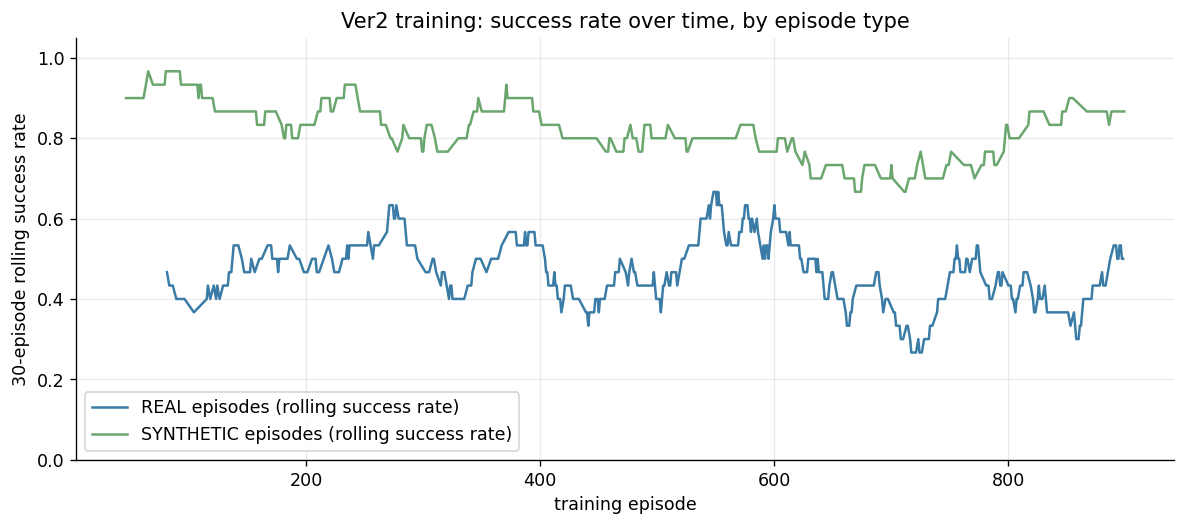

In [ ]:

lc = np.array(learning_curve, dtype=object)
succ = np.array([row[5] for row in learning_curve])
is_synth = np.array([row[6] for row in learning_curve])
last300 = np.arange(len(learning_curve)) >= len(learning_curve) - 300

print(f"Overall success rate: {succ.mean():.2f}")
print(f"Last 300 episodes -- synthetic success rate: {succ[last300 & (is_synth==1)].mean():.2f} "
      f"(n={int((last300 & (is_synth==1)).sum())})")
print(f"Last 300 episodes -- REAL success rate: {succ[last300 & (is_synth==0)].mean():.2f} "
      f"(n={int((last300 & (is_synth==0)).sum())})")

window = 30
def rolling(x, w):
    return np.convolve(x, np.ones(w) / w, mode="valid")

fig, ax = plt.subplots(figsize=(10, 4.5))
eps_idx = np.arange(len(learning_curve))
real_mask = is_synth == 0
syn_mask = is_synth == 1
if real_mask.sum() >= window:
    ax.plot(eps_idx[real_mask][window-1:], rolling(succ[real_mask].astype(float), window),
            color="#3a7ca5", label="REAL episodes (rolling success rate)")
if syn_mask.sum() >= window:
    ax.plot(eps_idx[syn_mask][window-1:], rolling(succ[syn_mask].astype(float), window),
            color="#6aa66e", label="SYNTHETIC episodes (rolling success rate)")
ax.set_xlabel("training episode")
ax.set_ylabel(f"{window}-episode rolling success rate")
ax.set_title("Ver2 training: success rate over time, by episode type")
ax.legend()
ax.set_ylim(0, 1.05)
fig.tight_layout()
plt.show()


In [ ]:
# Trivial episodes: the start count is already <= the target (nothing to do)
last = learning_curve[-300:]
real = [r for r in last if r[6] == 0]
triv = [r for r in real if r[2] <= r[4]]
non = [r for r in real if r[2] > r[4]]
print(f"Last 300 episodes, real: n={len(real)}, success={np.mean([r[5] for r in real]):.3f}")
print(f"  trivial (start <= target): {len(triv)} ({len(triv)/len(real):.1%})")
print(f"  non-trivial: n={len(non)}, success={np.mean([r[5] for r in non]):.3f}")


Last 300 episodes, real: n=203, success=0.419
  trivial (start <= target): 14 (6.9%)
  non-trivial: n=189, success=0.376


## Part 7 -- Statistical Evaluation on Held-Out Test Instances

5 (knot, slope) pairs never seen during training. Four of them use
knots that do appear in the training pool, at other slopes (`4_1`,
`5_2`, `6_1`, `6_3`); only `m009` is a new manifold. Each method is run
**10 times** per instance; mean +/- std reported, not a single
trajectory.

Caveats: each method starts from its own independently generated
triangulation (SnapPy's `filled_triangulation()` is randomized), so the
comparison is unpaired and noisy. And where the start is already at the
best-known value there is no headroom to show any difference (in the run
shown, `6_3(7,1)` and `m009(5,1)`; start counts vary between runs).

In [ ]:

TEST_INSTANCES = [("4_1", (7, 2)), ("5_2", (7, 1)), ("6_1", (7, 1)), ("6_3", (7, 1)), ("m009", (5, 1))]
MAX_STEPS = 60
N_TRIALS = 10


def run_rl(agent, triangulation, max_steps, epsilon=0.0):
    env = PachnerEnv(triangulation, max_steps=max_steps)
    s, actions = env.obs()
    for _ in range(max_steps):
        if not actions:
            break
        afs = [action_features(a) for a in actions]
        idx = agent.select(s, actions, afs, epsilon)
        r, done, ok = env.step(actions[idx])
        s, actions = env.obs()
        if done:
            break
    return env.best_count


results = {}
for knot, pq in TEST_INSTANCES:
    T, orig_vol, orig_id = get_triangulation(knot, pq)
    best_known, idstr = best_known_for_instance(knot, pq, n_restarts=100)

    rl_vals, greedy_vals, rand_vals = [], [], []
    for trial in range(N_TRIALS):
        T2, _, _ = get_triangulation(knot, pq)
        rl_vals.append(run_rl(agent, T2, MAX_STEPS, epsilon=0.05))
        T3, _, _ = get_triangulation(knot, pq)
        envg, _ = greedy_simplify(T3, max_steps=MAX_STEPS, rng=random.Random(2000 + trial))
        greedy_vals.append(envg.best_count)
        T4, _, _ = get_triangulation(knot, pq)
        envr, _ = random_walk_simplify(T4, max_steps=MAX_STEPS, seed=3000 + trial, patience=40, shrink_bias=0.3)
        rand_vals.append(envr.best_count)

    _, snappy_best = snappy_builtin_best_of(T, n_restarts=15)
    results[(knot, pq)] = {"start": T.num_tetrahedra(), "best_known": best_known,
                            "rl": np.array(rl_vals), "greedy": np.array(greedy_vals),
                            "random": np.array(rand_vals), "snappy": snappy_best}
    r = results[(knot, pq)]
    print(f"{knot}{pq}: start={r['start']}  best_known={best_known}  snappy={snappy_best}")
    print(f"  RL:     mean={r['rl'].mean():.2f} +/- {r['rl'].std():.2f}  (best={r['rl'].min()})")
    print(f"  greedy: mean={r['greedy'].mean():.2f} +/- {r['greedy'].std():.2f}  (best={r['greedy'].min()})")
    print(f"  random: mean={r['random'].mean():.2f} +/- {r['random'].std():.2f}  (best={r['random'].min()})")
    print()


4_1(7, 2): start=12  best_known=10  snappy=10
  RL:     mean=11.00 +/- 0.00  (best=11)
  greedy: mean=11.20 +/- 0.40  (best=11)
  random: mean=11.10 +/- 0.30  (best=11)



5_2(7, 1): start=11  best_known=10  snappy=10
  RL:     mean=10.40 +/- 0.49  (best=10)
  greedy: mean=10.40 +/- 0.49  (best=10)
  random: mean=10.60 +/- 0.49  (best=10)



6_1(7, 1): start=17  best_known=16  snappy=16
  RL:     mean=16.30 +/- 0.46  (best=16)
  greedy: mean=16.20 +/- 0.40  (best=16)
  random: mean=16.00 +/- 0.00  (best=16)



6_3(7, 1): start=17  best_known=17  snappy=17
  RL:     mean=18.10 +/- 0.54  (best=17)
  greedy: mean=17.70 +/- 0.46  (best=17)
  random: mean=18.00 +/- 0.45  (best=17)



m009(5, 1): start=11  best_known=11  snappy=11
  RL:     mean=11.00 +/- 0.00  (best=11)
  greedy: mean=11.00 +/- 0.00  (best=11)
  random: mean=11.00 +/- 0.00  (best=11)



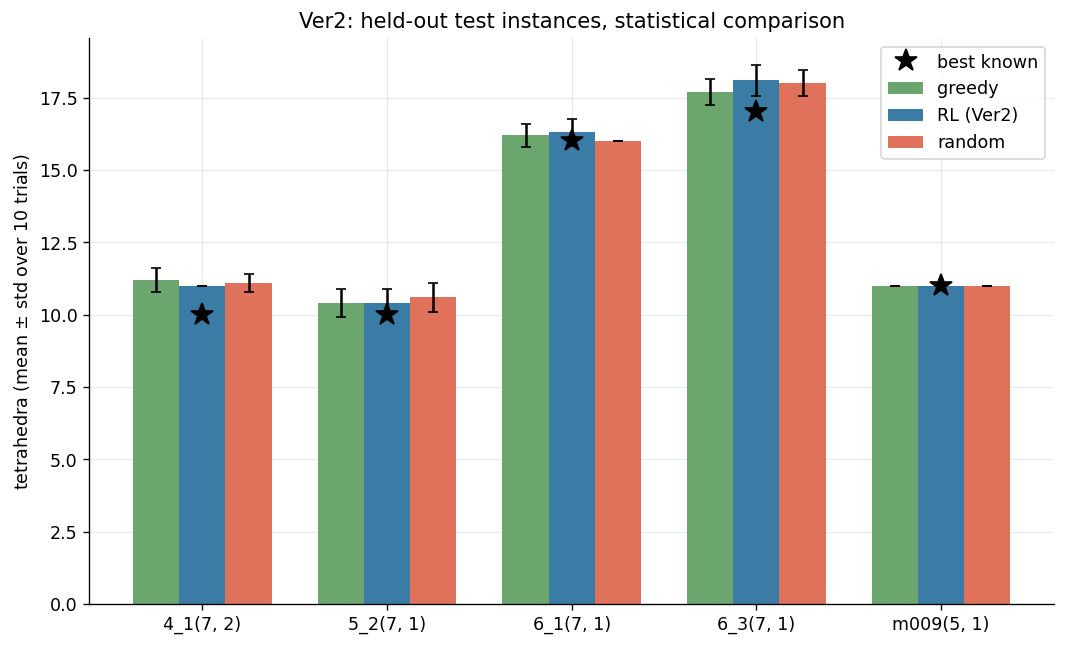

In [ ]:

fig, ax = plt.subplots(figsize=(9, 5.5))
labels = [f"{k}{pq}" for k, pq in TEST_INSTANCES]
x = np.arange(len(labels))
width = 0.25

rl_means = [results[kp]["rl"].mean() for kp in TEST_INSTANCES]
rl_stds = [results[kp]["rl"].std() for kp in TEST_INSTANCES]
greedy_means = [results[kp]["greedy"].mean() for kp in TEST_INSTANCES]
greedy_stds = [results[kp]["greedy"].std() for kp in TEST_INSTANCES]
random_means = [results[kp]["random"].mean() for kp in TEST_INSTANCES]
random_stds = [results[kp]["random"].std() for kp in TEST_INSTANCES]
best_known_vals = [results[kp]["best_known"] for kp in TEST_INSTANCES]

ax.bar(x - width, greedy_means, width, yerr=greedy_stds, capsize=3, label="greedy", color="#6aa66e")
ax.bar(x, rl_means, width, yerr=rl_stds, capsize=3, label="RL (Ver2)", color="#3a7ca5")
ax.bar(x + width, random_means, width, yerr=random_stds, capsize=3, label="random", color="#e0715a")
ax.plot(x, best_known_vals, "k*", markersize=14, label="best known", zorder=5)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("tetrahedra (mean $\\pm$ std over 10 trials)")
ax.set_title("Ver2: held-out test instances, statistical comparison")
ax.legend()
fig.tight_layout()
plt.show()


## Part 8 -- Local-Minimum Sanity Test

Greedy vs. RL, 10 trials each, on three instances (`6_1(5,1)`,
`6_2(7,1)`, `6_3(5,1)`) where 250 restarts of SnapPy's own simplifier
found no improvement.

Two caveats. All three instances are in the training pool (Part 5), so
this is not a held-out test. And for `6_1(5,1)` and `6_2(7,1)` no count
below the starting one is known, so there is nothing to escape *to*: the
test can show RL doing worse, but not RL escaping. Only `6_3(5,1)`
(best known 15, typical start 16) has any known headroom.

In [ ]:

STUCK_INSTANCES = [("6_1", (5, 1)), ("6_2", (7, 1)), ("6_3", (5, 1))]

sanity_results = {}
for knot, pq in STUCK_INSTANCES:
    T, orig_vol, orig_id = get_triangulation(knot, pq)
    rl_vals, greedy_vals = [], []
    for trial in range(N_TRIALS):
        T2, _, _ = get_triangulation(knot, pq)
        rl_vals.append(run_rl(agent, T2, MAX_STEPS, epsilon=0.05))
        T3, _, _ = get_triangulation(knot, pq)
        envg, _ = greedy_simplify(T3, max_steps=MAX_STEPS, rng=random.Random(5000 + trial))
        greedy_vals.append(envg.best_count)
    rl_vals, greedy_vals = np.array(rl_vals), np.array(greedy_vals)
    sanity_results[(knot, pq)] = {"start": T.num_tetrahedra(), "rl": rl_vals, "greedy": greedy_vals}
    print(f"{knot}{pq}: start={T.num_tetrahedra()}")
    print(f"  greedy: mean={greedy_vals.mean():.2f} +/- {greedy_vals.std():.2f}  (range {greedy_vals.min()}-{greedy_vals.max()})")
    print(f"  RL:     mean={rl_vals.mean():.2f} +/- {rl_vals.std():.2f}  (range {rl_vals.min()}-{rl_vals.max()})")
    print(f"  RL improvement over greedy (mean): {greedy_vals.mean() - rl_vals.mean():+.2f} tetrahedra")
    print()


6_1(5, 1): start=14
  greedy: mean=14.10 +/- 0.30  (range 14-15)
  RL:     mean=14.00 +/- 0.00  (range 14-14)
  RL improvement over greedy (mean): +0.10 tetrahedra



6_2(7, 1): start=10
  greedy: mean=10.00 +/- 0.00  (range 10-10)
  RL:     mean=10.00 +/- 0.00  (range 10-10)
  RL improvement over greedy (mean): +0.00 tetrahedra



6_3(5, 1): start=16
  greedy: mean=15.80 +/- 0.60  (range 15-17)
  RL:     mean=16.00 +/- 1.10  (range 15-19)
  RL improvement over greedy (mean): -0.20 tetrahedra



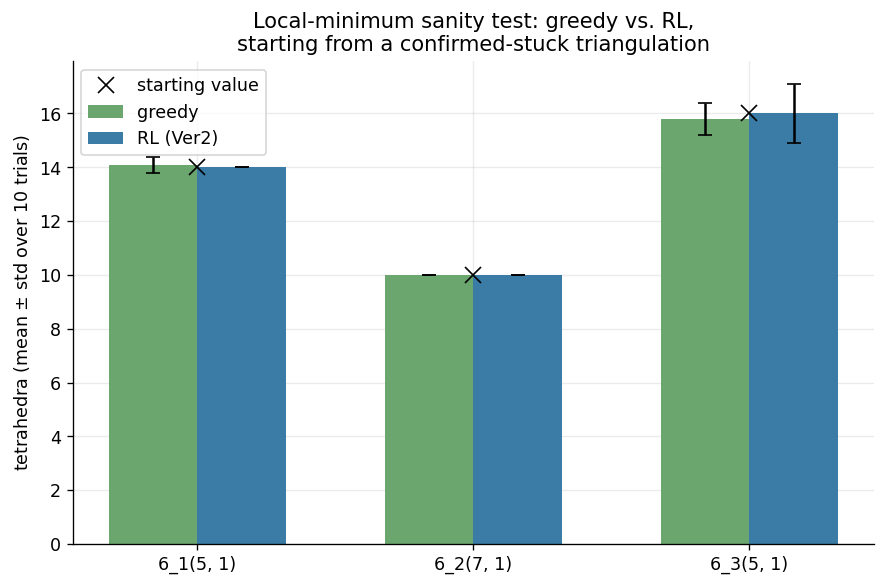

In [ ]:

fig, ax = plt.subplots(figsize=(7.5, 5))
labels2 = [f"{k}{pq}" for k, pq in STUCK_INSTANCES]
x2 = np.arange(len(labels2))
width2 = 0.32

g_means = [sanity_results[kp]["greedy"].mean() for kp in STUCK_INSTANCES]
g_stds = [sanity_results[kp]["greedy"].std() for kp in STUCK_INSTANCES]
r_means = [sanity_results[kp]["rl"].mean() for kp in STUCK_INSTANCES]
r_stds = [sanity_results[kp]["rl"].std() for kp in STUCK_INSTANCES]
starts = [sanity_results[kp]["start"] for kp in STUCK_INSTANCES]

ax.bar(x2 - width2/2, g_means, width2, yerr=g_stds, capsize=4, label="greedy", color="#6aa66e")
ax.bar(x2 + width2/2, r_means, width2, yerr=r_stds, capsize=4, label="RL (Ver2)", color="#3a7ca5")
ax.plot(x2, starts, "kx", markersize=10, label="starting value", zorder=5)
ax.set_xticks(x2); ax.set_xticklabels(labels2)
ax.set_ylabel("tetrahedra (mean $\\pm$ std over 10 trials)")
ax.set_title("Local-minimum sanity test: greedy vs. RL,\nstarting from a confirmed-stuck triangulation")
ax.legend()
fig.tight_layout()
plt.show()


## Part 9 -- Honest Conclusions

**What was fixed, and confirmed working:**
- The ground-truth bug (Part 1): comparisons are now against a properly
  computed, honestly-labeled "best known" value, not a value from an
  unrelated unfilled manifold. "Best known" is what bounded search
  found, not a proven minimum.
- The distribution-shift problem: training now includes real, augmented
  Dehn-filled triangulations (11 instances), not only synthetic
  scrambles. In Part 6 the real-episode success rate over the last 300
  training episodes is 42%, or about 38% once the ~7% trivial episodes
  (start already at or below target) are excluded. This is measured on
  the training pool, not held-out instances, and greedy was not run on
  the same episodes, so it is not evidence of an advantage over greedy.
  It also cannot be compared directly with Ver1: Ver1's learning curve
  was essentially flat (ratio near 1.0), and its targets came from the
  ground-truth bug, so a Ver1 "success" was not measured the same way.
- The exploration bias and discount-factor issues (Parts 2-3): fixed
  directly (`biased_choice`, `gamma=0.97`).

**What the statistics in Parts 7-8 actually show:** no measurable
difference between Ver2's RL agent and greedy, in either direction. Mean
differences are at most 0.4 tetrahedra (`6_3(7,1)`: RL 18.10 vs. greedy
17.70; sanity test `6_3(5,1)`: RL 16.00 vs. greedy 15.80), all within one
standard deviation, and the sign is not consistent across instances.
Ver1's RL also matched greedy on its instances, so this N=10 evidence
does not show an improvement from Ver1 to Ver2 (see the greedy-baseline
caveat below for a more powered comparison).
What changed is the correctness of the targets and the training
distribution, not a demonstrated advantage over greedy.

**Limits of this evaluation:**
- Unpaired: each method started from its own random triangulation.
- Low power: N=10, and some instances have little or no headroom
  (start already at the best-known value).
- Part 8's instances are in the training pool, and two of the three have
  no known lower count to reach.
- The `greedy_simplify` baseline picks its fallback move (when no 3-2 is
  available) from the flat action list, which is biased toward 2-3
  growth moves (the bias described in Part 2), so it is a handicapped
  baseline. A paired analysis on identical scrambled starts (in the
  report) found RL ahead of this greedy by about 12-14 points of success
  rate on real held-out instances, but level with a greedy that uses a
  type-balanced fallback (+1.2 points, 95% CI -2.1 to +4.6). Instance
  level differences against the balanced greedy go in both directions.
- Greedy was never compared on the synthetic scrambles in this notebook, so the 78%
  synthetic success rate does not show RL beating greedy: greedy may
  undo many scrambles by itself with 3-2 moves.

**Honest interpretation:** fixing the ground truth revealed the real gaps
in this problem are much smaller than Ver1's (buggy) numbers suggested --
often 0-2 tetrahedra, not 5-10. Fixing the training distribution put real
instances into training (the real-episode success curve in Part 6 is
roughly flat while the augmentation gets harder, so it does not by itself
show learning), and on held-out instances RL is at parity with a
balanced greedy search. The gap between
"parity with greedy" and "a method that reliably finds what greedy
cannot" likely needs the higher-effort directions flagged after Ver1:
pairing the learned value function with explicit tree search (MCTS/A*)
rather than deploying it as a bare policy, and richer, graph-based
state/action features (a GNN over the tetrahedron gluing graph) in place
of the current 6-dimensional hand-crafted features. The paired evaluation
with built-in headroom described above is the reference to build on.


## Part 10 -- 100-Tetrahedron Pachner Scramble Benchmark

This experiment starts from a genuine closed 3-manifold triangulation
(`4_1` filled at (5,1)), then **grows it to exactly 100 tetrahedra using
legal 2-3 Pachner moves**, with occasional neutral 4-4 moves mixed in. All
moves preserve the manifold: the 100-tetrahedron triangulation is a
deliberately complicated triangulation of the *same* manifold. The target
is the tetrahedron count of the original triangulation. It is reachable by
construction (the scramble can be reversed with 3-2 and 4-4 moves), but it
is not a proven minimum.

**Implementation note (a bug fixed in this version).** The scrambled
triangulation must stay an `Mcomplex`. Converting it back with
`snappy_manifold()` does *not* give the closed 100-tetrahedron
triangulation: it returns SnapPy's cusped presentation with a Dehn
filling (a 3-tetrahedron triangulation in the example here), so any count or
move made on that object is meaningless, and a benchmark built on it
"solves" itself immediately. `snappy_manifold()` is used below only to check
invariants (homology and hyperbolic volume, re-solving from a fresh triangulation of the same manifold when SnapPy's solver fails), never to count tetrahedra.

All methods start from the identical scramble (regenerated from the same
seed, and checked to have the same edge-valence signature):
- **RL**: the learned Q-function with a little exploration (epsilon = 0.05, as in
  the paired analysis). With epsilon = 0 the policy is deterministic and can loop
  forever in a 2-3 / 3-2 cycle, which makes RL look worse than it is.
- **greedy**: the notebook baseline. It takes a 3-2 move when one exists,
  otherwise a uniformly random move from the flat action list (biased toward
  2-3 growth moves), and stops after more than 6 consecutive non-reducing
  steps.
- **greedy_balanced**: the same, but the fallback move is type-balanced.

The RL agent was trained on starts of at most 27 tetrahedra, so 100 is
about 4x out of distribution.


In [ ]:
# ---------- 100-tetrahedron generator (fixed) ----------

LARGE_TARGET_TETS = 100
LARGE_MAX_STEPS = 180
LARGE_SEED = 12345


def env_from_mcomplex(mc, max_steps=LARGE_MAX_STEPS):
    # Create a PachnerEnv from an already-built Mcomplex without changing it.
    env = PachnerEnv.__new__(PachnerEnv)
    env.mc = mc
    env.start_count = len(mc.Tetrahedra)
    env.max_steps = max_steps
    env.steps = 0
    env.best_count = env.start_count
    return env


def grow_to_exact_tets(base_triangulation, target_tets=100, seed=0,
                       four_four_probability=0.15, max_attempts=20000):
    # Count-changing moves are exclusively 2-3; 4-4 moves are optional neutral
    # moves so the scramble is not a straight stack of 2-3s.
    rng = random.Random(seed)
    mc = build_mcomplex(base_triangulation.copy())
    if len(mc.Tetrahedra) > target_tets:
        raise ValueError(f"Base triangulation already has {len(mc.Tetrahedra)} tetrahedra.")
    history = []
    attempts = 0
    while len(mc.Tetrahedra) < target_tets:
        if attempts >= max_attempts:
            raise RuntimeError(f"Could not reach {target_tets} tetrahedra; at {len(mc.Tetrahedra)}.")
        attempts += 1
        acts = legal_actions(mc)
        grow = [a for a in acts if a[0] == "2-3"]
        neutral = [a for a in acts if a[0] == "4-4"]
        if neutral and rng.random() < four_four_probability:
            action = rng.choice(neutral)
        elif grow:
            action = rng.choice(grow)
        elif neutral:
            action = rng.choice(neutral)
        else:
            raise RuntimeError("No legal 2-3 or 4-4 move is available.")
        try:
            if action[0] == "2-3":
                ok = mc.two_to_three(action[2], action[1], must_succeed=False)
            else:
                ok = mc.four_to_four(action[1].get_arrow(), must_succeed=False)
        except Exception:
            ok = False
        if ok:
            mc.rebuild()
            history.append(action[0])
    return mc, history


def make_base_problem(manifold_name="4_1", filling=(5, 1)):
    M = snappy.Manifold(manifold_name)
    M.dehn_fill(filling)
    base_T = M.filled_triangulation()
    return base_T, base_T.num_tetrahedra(), float(M.volume()), str(M.homology())


def check_manifold(mc, ref_volume, ref_homology, rescue_tries=25):
    # snappy_manifold() is fine for invariants but NOT for counting tetrahedra.
    # Volume is only meaningful when SnapPy's solver converged (it sometimes
    # returns a degenerate solution for a perfectly valid triangulation), and
    # only for a hyperbolic filling. If it did not converge, re-derive a fresh
    # closed triangulation of the same manifold and re-solve, up to
    # rescue_tries times. Homology is the weaker fallback check.
    Mx = mc.snappy_manifold()
    if str(Mx.homology()) != ref_homology:
        return "MISMATCH (H1)"
    for _ in range(rescue_tries + 1):
        if Mx.solution_type() == "all tetrahedra positively oriented":
            ok = abs(float(Mx.volume()) - ref_volume) < 1e-6
            return "ok (H1 + volume)" if ok else "MISMATCH (volume)"
        Mx = build_mcomplex(Mx.filled_triangulation()).snappy_manifold()
    return "H1 only (volume solver failed)"


def start_signature(mc):
    return (len(mc.Tetrahedra), tuple(sorted(e.valence() for e in mc.Edges)))


def rl_on_env(env, the_agent, epsilon=0.0, seed=0):
    the_agent.rng = random.Random(seed)
    trace = [env.tet_count()]
    s, acts = env.obs()
    for _ in range(env.max_steps):
        if not acts:
            break
        afs = [action_features(a) for a in acts]
        idx = the_agent.select(s, acts, afs, epsilon)
        _, done, ok = env.step(acts[idx])
        trace.append(env.tet_count())
        s, acts = env.obs()
        if done:
            break
    return trace


def greedy_on_env(env, rng, balanced=False, patience=6):
    trace = [env.tet_count()]
    no_improve = 0
    for _ in range(env.max_steps):
        acts = env.current_actions()
        if not acts:
            break
        reducing = [a for a in acts if a[0] == "3-2"]
        if reducing:
            a = rng.choice(reducing)
        elif balanced:
            a = acts[biased_choice(acts, rng, shrink_bias=0.0)]
        else:
            a = rng.choice(acts)
        no_improve = 0 if reducing else no_improve + 1
        env.step(a)
        trace.append(env.tet_count())
        if no_improve > patience:
            break
    return trace


print("Large-scramble generator defined.")


Large-scramble generator defined.


In [ ]:
# ---------- one scramble: every method from the SAME 100-tet start ----------

bench_agent = agent   # swap in `large_agent` here after the optional training below
RL_EPSILON = 0.05     # a purely deterministic policy (epsilon = 0) can loop forever in a 2-3 / 3-2 cycle
base_T, LARGE_TARGET, base_vol, base_h1 = make_base_problem("4_1", (5, 1))


def run_method(name, seed, max_steps):
    mc, hist = grow_to_exact_tets(base_T, LARGE_TARGET_TETS, seed=seed)
    env = env_from_mcomplex(mc, max_steps)
    sig = start_signature(mc)
    if name == "rl":
        trace = rl_on_env(env, bench_agent, epsilon=RL_EPSILON, seed=seed)
    else:
        trace = greedy_on_env(env, random.Random(seed), balanced=(name == "greedy_balanced"))
    return env, trace, sig, hist


results = {name: run_method(name, LARGE_SEED, LARGE_MAX_STEPS)
           for name in ("rl", "greedy", "greedy_balanced")}
assert len({r[2] for r in results.values()}) == 1, "methods did not start from the same triangulation"

hist = results["rl"][3]
print("Original triangulation tetrahedra (target):", LARGE_TARGET)
print("Scrambled tetrahedra (Mcomplex):", results["rl"][2][0])
print("Pachner moves used:", len(hist), " 2-3:", hist.count("2-3"), " 4-4:", hist.count("4-4"))
print()
for name, (env, trace, sig, _) in results.items():
    print(f"{name:16s} best={env.best_count:3d} final={env.tet_count():3d} steps={len(trace)-1:3d} "
          f"reached target={env.best_count <= LARGE_TARGET}  check: {check_manifold(env.mc, base_vol, base_h1)}")


Original triangulation tetrahedra (target): 9
Scrambled tetrahedra (Mcomplex): 100
Pachner moves used: 106  2-3: 91  4-4: 15

rl               best= 31 final= 32 steps=180 reached target=False  check: ok (H1 + volume)
greedy           best=  9 final=  9 steps=180 reached target=True  check: ok (H1 + volume)
greedy_balanced  best=  9 final=  9 steps=180 reached target=True  check: ok (H1 + volume)


In [ ]:
# ---------- statistics over many scrambles (same base triangulation, same scrambles) ----------

N_SCRAMBLES = 20
NAMES = ("rl", "greedy", "greedy_balanced")
large_stats = {}
for budget in (180, 600):
    rows = []
    for k in range(N_SCRAMBLES):
        per = {}
        for name in NAMES:
            env, trace, _, _ = run_method(name, LARGE_SEED + k, budget)
            per[name] = (env.best_count, check_manifold(env.mc, base_vol, base_h1))
        rows.append(per)
    large_stats[budget] = rows
    print(f"--- budget {budget} steps, {N_SCRAMBLES} scrambles of exactly {LARGE_TARGET_TETS} tets, target {LARGE_TARGET} ---")
    for name in NAMES:
        b = np.array([r[name][0] for r in rows])
        checks = Counter(r[name][1] for r in rows)
        print(f"{name:16s} mean best {b.mean():5.1f}  median {np.median(b):4.0f}  min {b.min():3d}  "
              f"reached target {int((b <= LARGE_TARGET).sum()):2d}/{N_SCRAMBLES}  checks: {dict(checks)}")


--- budget 180 steps, 20 scrambles of exactly 100 tets, target 9 ---
rl               mean best  24.2  median   24  min  18  reached target  0/20  checks: {'ok (H1 + volume)': 20}
greedy           mean best  22.9  median   24  min   9  reached target  2/20  checks: {'ok (H1 + volume)': 20}
greedy_balanced  mean best  17.6  median   16  min   9  reached target  5/20  checks: {'ok (H1 + volume)': 20}


--- budget 600 steps, 20 scrambles of exactly 100 tets, target 9 ---
rl               mean best  17.1  median   16  min   9  reached target  5/20  checks: {'ok (H1 + volume)': 20}
greedy           mean best  10.7  median    9  min   9  reached target 14/20  checks: {'ok (H1 + volume)': 20}
greedy_balanced  mean best  15.1  median   11  min   9  reached target  9/20  checks: {'ok (H1 + volume)': 20}


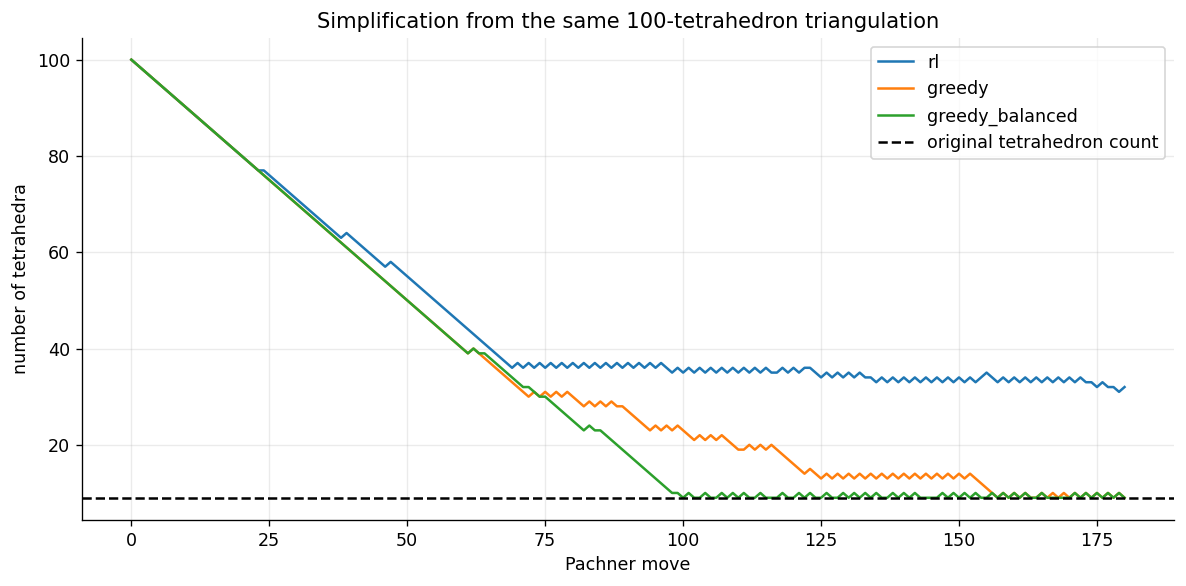

In [ ]:
# Plot the simplification trajectories from the single-scramble run above.
fig, ax = plt.subplots(figsize=(10, 5))
for name, (env, trace, _, _) in results.items():
    ax.plot(np.arange(len(trace)), trace, label=name)
ax.axhline(LARGE_TARGET, linestyle="--", color="k", label="original tetrahedron count")
ax.set_xlabel("Pachner move")
ax.set_ylabel("number of tetrahedra")
ax.set_title("Simplification from the same 100-tetrahedron triangulation")
ax.legend()
fig.tight_layout()
plt.show()


### Reading Part 10

In the run shown, every method starts from exactly 100 tetrahedra and every
final triangulation passes the manifold check (homology and hyperbolic volume
both match the original), so the moves and the scramble are sound. What the
comparison shows:

- With a 180-step budget the agent reaches the target on none of the 20
  scrambles (mean best count 24.2), against 2 of 20 for greedy and 5 of 20
  for balanced greedy. With a 600-step budget it reaches it on 5 of 20,
  against 14 of 20 and 9 of 20.
- RL is run with epsilon = 0.05. With a purely deterministic policy
  (epsilon = 0) RL did worse in the runs tried, because it can loop forever in
  a 2-3 / 3-2 cycle.
- The agent was trained on starts of at most 27 tetrahedra, so this is an
  out-of-distribution test of *this checkpoint*, not of the method at scale.
  Training on 100-tetrahedron scrambles (optional cell below) is the fair
  test.
- The base triangulation comes from SnapPy's randomized
  `filled_triangulation()`, so the target (9 or 10) and the exact counts
  change between runs. In the runs tried, the agent was never ahead of both
  greedy variants at the 600-step budget.
- Both greedy variants stop after more than 6 consecutive non-reducing steps,
  while RL uses the whole budget. The notebook's greedy rarely stalls because
  its flat-list fallback keeps creating new 3-2 opportunities; the balanced
  variant stalls sooner. So the two greedies are not directly comparable
  with each other on a fixed budget.
- This is 20 scrambles of one manifold. It says nothing about other manifolds.


### Optional: simple from-scratch training loop (superseded by Part 11)

This loop trains a fresh agent from scratch on 100-tetrahedron scrambles. It
works on `Mcomplex` objects directly, so it was not affected by the
conversion bug above, but it is slow (about 25 seconds per episode, so
roughly two hours for its default 300 episodes) and has no target network or
size curriculum. **Part 11 below is the recommended way** to train on the
100-tetrahedron problem.


In [ ]:
LARGE_TRAIN_EPISODES = 300
LARGE_TRAIN_MAX_STEPS = 180


def train_large_agent(base_T, episodes=LARGE_TRAIN_EPISODES, seed=LARGE_SEED):
    """Train a fresh Q-agent on exact-100-tet scrambles of base_T."""
    rng = random.Random(seed)
    large_agent = PachnerQAgent(hidden=(64, 64), gamma=0.99, seed=seed)
    successes = 0

    for ep in range(episodes):
        # Different scramble every episode, same underlying manifold.
        mc, _ = grow_to_exact_tets(
            base_T, target_tets=100, seed=rng.randrange(10**9),
            four_four_probability=0.20
        )
        env = env_from_mcomplex(mc, max_steps=LARGE_TRAIN_MAX_STEPS)
        epsilon = max(0.05, 1.0 - ep / max(1, episodes - 1))

        s, actions = env.obs()
        succeeded = False
        target = base_T.num_tetrahedra()

        for _ in range(LARGE_TRAIN_MAX_STEPS):
            if not actions:
                break
            afs = [action_features(a) for a in actions]
            idx = large_agent.select(s, actions, afs, epsilon=epsilon)
            r, done, ok = env.step(actions[idx])
            new = env.tet_count()
            if new <= target:
                r += 5.0
                done = True
                succeeded = True
            s_next, actions_next = env.obs()
            next_afs = [action_features(a) for a in actions_next]
            large_agent.remember(s, afs[idx], r, s_next, next_afs, done)
            large_agent.train_batch(batch_size=256)
            s, actions = s_next, actions_next
            if done:
                break

        successes += int(succeeded)
        if (ep + 1) % 25 == 0:
            print(f"episode {ep+1:4d}/{episodes}: success={successes/(ep+1):.3f}")

    return large_agent


# Uncomment to train:
# large_agent = train_large_agent(base_T)
# Then replace `agent` by `large_agent` in the benchmark above.


## Part 11 -- Train the RL agent on the 100-tetrahedron problem, then compete again

Part 10 showed that the agent from Part 5, trained on starts of at most 27
tetrahedra, is out of distribution at 100. Here we **fine-tune it on
100-tetrahedron scrambles** and re-run the competition against both greedy
baselines.

Design choices, and why:
- **Warm start** from the Part 5 agent, with a fresh replay buffer.
- **Size curriculum.** Scramble sizes grow from about 20 tetrahedra up to
  100 over the first 60% of the episodes, and the rest are mostly exactly 100.
  Early episodes are easy, so the agent sees successes (the Ver1 lesson:
  with only hard episodes no successes ever occur).
- **Both step budgets (180 and 600) are sampled**, because the state includes
  the fraction of steps left and the competition uses both.
- **Stable Fitted-Q.** A first attempt with plain bootstrapping and
  gamma = 0.99 diverged: after 18 episodes the mean Q-value was about 52,000
  (returns are at most about 100). The version below uses a frozen target
  network (re-synced every 150 updates) and clipped targets, and prints the
  mean Q so divergence is visible. It also does one vectorized network call
  per batch instead of one per sample, which made it about 6x faster.
- **No leakage.** Training and evaluation scrambles use different seeds, and
  the competition also includes a manifold the agent never trained on.

The training cell is resumable: the checkpoint is written atomically, so
re-running it continues where it stopped. 200 episodes take roughly 15
minutes on one CPU.


In [ ]:
# ---------- Part 11a: train the agent on 100-tetrahedron scrambles ----------
import copy, json, os, pickle, time

LARGE_TRAIN_EPISODES = 200
LARGE_CKPT = "large100_checkpoint.pkl"
LARGE_GAMMA = 0.99
LARGE_TRAIN_BUDGETS = (180, 600)
LARGE_TIME_LIMIT = None      # seconds per run of this cell; set e.g. 240 to train in chunks
SUCCESS_BONUS = 5.0


def fast_train_batch(ag, batch_size=64, clip=(-10.0, 100.0), sync_every=150):
    # Vectorized Fitted-Q update with a frozen target network and clipped targets.
    if len(ag.replay) < 64:
        return
    if getattr(ag, "target_model", None) is None:
        ag.target_model = copy.deepcopy(ag.model)
        ag.n_updates = 0
    batch = ag.rng.sample(ag.replay, min(batch_size, len(ag.replay)))
    X = np.stack([np.concatenate([b[0], b[1]]) for b in batch])
    y = np.array([b[2] for b in batch], dtype=float)
    rows, owners = [], []
    for i, (s, a, r, s_next, nafs, done) in enumerate(batch):
        if not done and len(nafs):
            rows.append(np.hstack([np.repeat(s_next[None, :], len(nafs), axis=0), nafs]))
            owners.append((i, len(nafs)))
    if rows:
        q = ag.target_model.predict(np.vstack(rows))
        starts = np.cumsum([0] + [n for _, n in owners[:-1]])
        qmax = np.maximum.reduceat(q, starts)
        for (i, _), m in zip(owners, qmax):
            y[i] += ag.gamma * float(m)
    y = np.clip(y, clip[0], clip[1])
    ag.model.partial_fit(X, y)
    ag.fitted = True
    ag.n_updates += 1
    if ag.n_updates % sync_every == 0:
        ag.target_model = copy.deepcopy(ag.model)


def curriculum_size(ep, total, rng):
    ramp = int(0.6 * total)
    if ep < ramp:
        top = int(30 + 70 * ep / max(1, ramp))
        return rng.randint(20, max(21, top))
    return 100 if rng.random() < 0.7 else rng.randint(30, 100)


def save_large_checkpoint(ag, episode, log):
    tmp = LARGE_CKPT + ".tmp"
    with open(tmp, "wb") as f:
        pickle.dump(dict(model=ag.model, target_model=getattr(ag, "target_model", None),
                         n_updates=getattr(ag, "n_updates", 0), rng_state=ag.rng.getstate(),
                         replay=ag.replay[-4000:], episode=episode, log=log), f)
    os.replace(tmp, LARGE_CKPT)


def mean_q(ag, n=500):
    rp = ag.replay[-n:]
    if not rp or not ag.fitted:
        return float("nan")
    return float(ag.model.predict(np.stack([np.concatenate([t[0], t[1]]) for t in rp])).mean())


def run_large_training(ag, base_T, target, ep_from, total, log, time_limit=None):
    t_start = time.time()
    for ep in range(ep_from, total):
        if time_limit is not None and time.time() - t_start > time_limit:
            return ep
        rng = random.Random(1_000_003 * ep + 17)
        size = curriculum_size(ep, total, rng)
        budget = rng.choice(LARGE_TRAIN_BUDGETS)
        eps = max(0.05, 0.5 - 0.45 * ep / max(1, int(0.6 * total)))
        mc, _ = grow_to_exact_tets(base_T, target_tets=size, seed=rng.randrange(10**9),
                                   four_four_probability=0.2)
        env = env_from_mcomplex(mc, budget)
        s, acts = env.obs()
        reached, n = False, 0
        t0 = time.time()
        for _ in range(budget):
            if not acts:
                break
            afs = [action_features(a) for a in acts]
            i = ag.select(s, acts, afs, eps)
            r, done, ok = env.step(acts[i])
            n += 1
            if env.tet_count() <= target:
                r += SUCCESS_BONUS
                done = True
                reached = True
            s2, acts2 = env.obs()
            nafs = (np.array([action_features(a) for a in acts2], dtype=np.float32)
                    if acts2 else np.zeros((0, 6), np.float32))
            ag.replay.append((s, afs[i], r, s2, nafs, done))
            if len(ag.replay) > 20000:
                ag.replay.pop(0)
            if n % 2 == 0:
                fast_train_batch(ag)
            s, acts = s2, acts2
            if done:
                break
        log.append(dict(ep=ep, size=size, budget=budget, eps=round(eps, 3), steps=n,
                        best=env.best_count, reached=bool(reached), secs=round(time.time() - t0, 1)))
        if (ep + 1) % 5 == 0:
            save_large_checkpoint(ag, ep + 1, log)
        if (ep + 1) % 10 == 0:
            last = log[-10:]
            print(f"episodes {ep-8:3d}-{ep+1:3d} | sizes {min(r['size'] for r in last):3d}-{max(r['size'] for r in last):3d}"
                  f" | reached {sum(r['reached'] for r in last):2d}/10 | mean best {np.mean([r['best'] for r in last]):5.1f}"
                  f" | mean Q {mean_q(ag):5.1f}")
    return total


def print_training_summary(log, total):
    print("Training summary by phase (reached the original size during training, exploration still on):")
    for lo in range(0, total, 50):
        g = [r for r in log if lo <= r["ep"] < lo + 50]
        if not g:
            continue
        big = [r for r in g if r["size"] >= 90]
        print(f"  episodes {lo:3d}-{min(lo + 50, total):3d}: reached {sum(r['reached'] for r in g):2d}/{len(g)}"
              f" | starts of 90+ tetrahedra: {sum(r['reached'] for r in big)}/{len(big)}")


# ---- build or resume the agent ----
large_agent = copy.deepcopy(agent)          # warm start from the Part 5 agent
large_agent.gamma = LARGE_GAMMA
large_agent.replay = []
large_agent.target_model = None
large_agent.n_updates = 0
ep_done, large_log = 0, []
if os.path.exists(LARGE_CKPT):
    with open(LARGE_CKPT, "rb") as f:
        st = pickle.load(f)
    large_agent.model = st["model"]
    large_agent.target_model = st["target_model"]
    large_agent.n_updates = st["n_updates"]
    large_agent.fitted = True
    large_agent.rng.setstate(st["rng_state"])
    large_agent.replay = st["replay"]
    ep_done, large_log = st["episode"], st["log"]
    print(f"Resuming from {LARGE_CKPT}: {ep_done}/{LARGE_TRAIN_EPISODES} episodes already done.")

if ep_done < LARGE_TRAIN_EPISODES:
    train_base_T, train_target, _, _ = make_base_problem("4_1", (5, 1))
    print(f"Training manifold: 4_1 filled at (5,1); original size (target) = {train_target}")
    ep_done = run_large_training(large_agent, train_base_T, train_target, ep_done,
                                 LARGE_TRAIN_EPISODES, large_log, time_limit=LARGE_TIME_LIMIT)
    save_large_checkpoint(large_agent, ep_done, large_log)
print(f"Done: {ep_done}/{LARGE_TRAIN_EPISODES} episodes.  Mean Q on recent replay: {mean_q(large_agent):.1f}")
print_training_summary(large_log, LARGE_TRAIN_EPISODES)


Resuming from large100_checkpoint.pkl: 200/200 episodes already done.
Done: 200/200 episodes.  Mean Q on recent replay: 4.7
Training summary by phase (reached the original size during training, exploration still on):
  episodes   0- 50: reached 42/50 | starts of 90+ tetrahedra: 0/0
  episodes  50-100: reached 30/50 | starts of 90+ tetrahedra: 0/0
  episodes 100-150: reached 21/50 | starts of 90+ tetrahedra: 8/27
  episodes 150-200: reached 11/50 | starts of 90+ tetrahedra: 8/41


In [ ]:
# ---------- Part 11b: the competition (identical scrambles for every method) ----------
import pickle
from collections import Counter

EVAL_SCRAMBLES = 15
EVAL_BUDGETS = (180, 600)
EVAL_SEED0 = 777000          # training used other seeds, so these scrambles are unseen
CHECKED_PER_METHOD = 3       # manifold check (homology + volume) on the first few scrambles
RESULTS_PKL = "large100_compete.pkl"
EVAL_CONFIG = (EVAL_SCRAMBLES, EVAL_BUDGETS, EVAL_SEED0)

# Each RL agent is run twice: epsilon = 0 (purely deterministic, can loop forever
# in a 2-3 / 3-2 cycle) and epsilon = 0.05 (the setting used in the paired analysis).
COMPETITORS = {
    "RL Part 5, eps 0": ("rl", agent, 0.0),
    "RL Part 5, eps 0.05": ("rl", agent, 0.05),
    "RL trained, eps 0": ("rl", large_agent, 0.0),
    "RL trained, eps 0.05": ("rl", large_agent, 0.05),
    "greedy": ("greedy", False, None),
    "greedy balanced": ("greedy", True, None),
}

compete_results = {}
if os.path.exists(RESULTS_PKL):
    with open(RESULTS_PKL, "rb") as f:
        saved = pickle.load(f)
    if saved.get("_config") == EVAL_CONFIG:
        compete_results = saved
compete_results["_config"] = EVAL_CONFIG


def run_competition(label, manifold, filling):
    base_T, target, ref_vol, ref_h1 = make_base_problem(manifold, filling)
    out = {"target": target, "budgets": {}, "checks": {}}
    print(f"{label}: original size (target) = {target}, {EVAL_SCRAMBLES} scrambles of {LARGE_TARGET_TETS} tetrahedra")
    for budget in EVAL_BUDGETS:
        rows = {name: [] for name in COMPETITORS}
        checks = {name: Counter() for name in COMPETITORS}
        for k in range(EVAL_SCRAMBLES):
            seed = EVAL_SEED0 + k
            for name, (kind, arg, eps) in COMPETITORS.items():
                mc, _ = grow_to_exact_tets(base_T, LARGE_TARGET_TETS, seed=seed)
                env = env_from_mcomplex(mc, budget)
                if kind == "rl":
                    rl_on_env(env, arg, epsilon=eps, seed=seed)
                else:
                    greedy_on_env(env, random.Random(seed), balanced=arg)
                rows[name].append(env.best_count)
                if k < CHECKED_PER_METHOD:
                    checks[name][check_manifold(env.mc, ref_vol, ref_h1)] += 1
        out["budgets"][budget] = rows
        out["checks"][budget] = {n: dict(c) for n, c in checks.items()}
        print(f"  budget {budget} moves:")
        for name in COMPETITORS:
            b = np.array(rows[name])
            print(f"    {name:20s} reached {int((b <= target).sum()):2d}/{EVAL_SCRAMBLES}  mean best {b.mean():5.1f}  median {np.median(b):4.0f}")
        for rl_name in ("RL Part 5, eps 0.05", "RL trained, eps 0.05"):
            a, b = np.array(rows[rl_name]), np.array(rows["greedy balanced"])
            print(f"    {rl_name} vs greedy balanced (lower best count): better in {(a < b).sum()}, worse in {(a > b).sum()}, tied in {(a == b).sum()}")
        allchecks = Counter()
        for c in checks.values():
            allchecks.update(c)
        print(f"    manifold checks: {dict(allchecks)}")
    return out


In [ ]:
# ---------- Part 11c: the manifold we trained on (new, unseen scrambles) ----------
label = "trained manifold 4_1(5,1)"
if label not in compete_results:
    compete_results[label] = run_competition(label, "4_1", (5, 1))
    with open(RESULTS_PKL, "wb") as f:
        pickle.dump(compete_results, f)
else:
    print(label, "already computed; delete", RESULTS_PKL, "to recompute")


trained manifold 4_1(5,1): original size (target) = 9, 15 scrambles of 100 tetrahedra


  budget 180 moves:
    RL Part 5, eps 0     reached  1/15  mean best  24.5  median   23
    RL Part 5, eps 0.05  reached  1/15  mean best  19.3  median   19
    RL trained, eps 0    reached  1/15  mean best  21.7  median   21
    RL trained, eps 0.05 reached  0/15  mean best  21.2  median   22
    greedy               reached  2/15  mean best  21.3  median   21
    greedy balanced      reached  2/15  mean best  20.7  median   19
    RL Part 5, eps 0.05 vs greedy balanced (lower best count): better in 8, worse in 7, tied in 0
    RL trained, eps 0.05 vs greedy balanced (lower best count): better in 7, worse in 8, tied in 0
    manifold checks: {'ok (H1 + volume)': 18}


  budget 600 moves:
    RL Part 5, eps 0     reached  1/15  mean best  17.8  median   17
    RL Part 5, eps 0.05  reached  3/15  mean best  16.2  median   16
    RL trained, eps 0    reached  0/15  mean best  21.1  median   22
    RL trained, eps 0.05 reached  4/15  mean best  17.3  median   18
    greedy               reached  7/15  mean best  11.6  median   11
    greedy balanced      reached  7/15  mean best  14.9  median   12
    RL Part 5, eps 0.05 vs greedy balanced (lower best count): better in 7, worse in 7, tied in 1
    RL trained, eps 0.05 vs greedy balanced (lower best count): better in 5, worse in 8, tied in 2
    manifold checks: {'ok (H1 + volume)': 18}


In [ ]:
# ---------- Part 11d: a manifold the agent never trained on ----------
label = "unseen manifold 5_2(7,1)"
if label not in compete_results:
    compete_results[label] = run_competition(label, "5_2", (7, 1))
    with open(RESULTS_PKL, "wb") as f:
        pickle.dump(compete_results, f)
else:
    print(label, "already computed; delete", RESULTS_PKL, "to recompute")


unseen manifold 5_2(7,1): original size (target) = 10, 15 scrambles of 100 tetrahedra


  budget 180 moves:
    RL Part 5, eps 0     reached  0/15  mean best  27.5  median   27
    RL Part 5, eps 0.05  reached  0/15  mean best  26.6  median   30
    RL trained, eps 0    reached  0/15  mean best  24.4  median   25
    RL trained, eps 0.05 reached  1/15  mean best  25.3  median   27
    greedy               reached  0/15  mean best  27.9  median   28
    greedy balanced      reached  0/15  mean best  23.4  median   22
    RL Part 5, eps 0.05 vs greedy balanced (lower best count): better in 4, worse in 11, tied in 0
    RL trained, eps 0.05 vs greedy balanced (lower best count): better in 7, worse in 8, tied in 0
    manifold checks: {'ok (H1 + volume)': 18}


  budget 600 moves:
    RL Part 5, eps 0     reached  1/15  mean best  17.5  median   18
    RL Part 5, eps 0.05  reached  3/15  mean best  16.1  median   17
    RL trained, eps 0    reached  0/15  mean best  23.4  median   24
    RL trained, eps 0.05 reached  4/15  mean best  18.6  median   17
    greedy               reached  2/15  mean best  12.4  median   12
    greedy balanced      reached  4/15  mean best  18.2  median   13
    RL Part 5, eps 0.05 vs greedy balanced (lower best count): better in 6, worse in 7, tied in 2
    RL trained, eps 0.05 vs greedy balanced (lower best count): better in 7, worse in 6, tied in 2
    manifold checks: {'ok (H1 + volume)': 18}


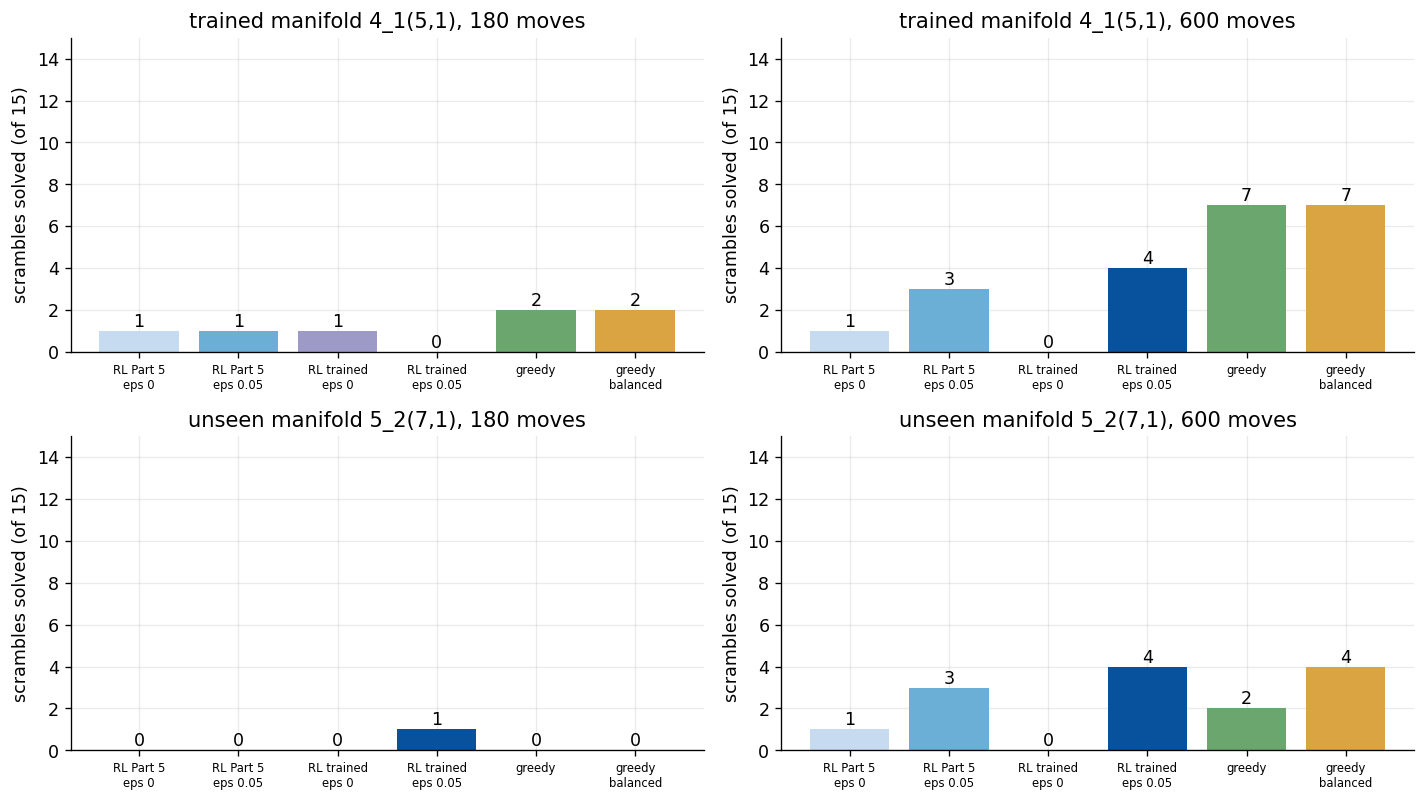

In [ ]:
# ---------- Part 11e: summary plot ----------
labels = [k for k in compete_results if not k.startswith("_")]
colors = {"RL Part 5, eps 0": "#c6dbef", "RL Part 5, eps 0.05": "#6baed6", "RL trained, eps 0": "#9e9ac8", "RL trained, eps 0.05": "#08519c", "greedy": "#6aa66e", "greedy balanced": "#d9a441"}
fig, axes = plt.subplots(len(labels), len(EVAL_BUDGETS), figsize=(12, 3.4 * len(labels)), squeeze=False)
for r, label in enumerate(labels):
    res = compete_results[label]
    for c, budget in enumerate(EVAL_BUDGETS):
        ax = axes[r][c]
        vals = [int((np.array(res["budgets"][budget][n]) <= res["target"]).sum()) for n in COMPETITORS]
        ax.bar(range(len(vals)), vals, color=[colors[n] for n in COMPETITORS])
        for i, v in enumerate(vals):
            ax.text(i, v + 0.2, str(v), ha="center")
        ax.set_xticks(range(len(vals)))
        ax.set_xticklabels([n.replace(", ", "\n").replace("greedy balanced", "greedy\nbalanced") for n in COMPETITORS], fontsize=7)
        ax.set_ylim(0, EVAL_SCRAMBLES)
        ax.set_title(f"{label}, {budget} moves")
        ax.set_ylabel(f"scrambles solved (of {EVAL_SCRAMBLES})")
fig.tight_layout()
plt.show()


### Reading Part 11

In the run shown (15 unseen scrambles per manifold; one draw of SnapPy's random
base triangulation per manifold):

- **Training on 100-tetrahedron scrambles did not make the agent beat the greedy
  methods, and it did not clearly beat the Part 5 agent either.** At 600 moves
  on the trained manifold, the trained agent (epsilon 0.05) reaches the original
  size on 4 of 15 scrambles, against 3 for the Part 5 agent and 7 for both greedy
  methods. On the unseen manifold it is 4 against 3, with 2 for greedy and 4 for
  balanced greedy. At 180 moves almost nobody gets there.
- **Exploration matters a lot for RL.** With epsilon = 0 the trained agent
  solves 0 of 15 at 600 moves on both manifolds, against 4 of 15 with
  epsilon = 0.05. A deterministic policy can loop in a 2-3 / 3-2 cycle.
- **The training-time success rate is not this comparison.** During training
  the agent reached the original size in 16 of 68 episodes that started at 90+
  tetrahedra (24%), but with exploration on, a mix of budgets and a different
  draw of the target. The competition uses fresh scrambles.
- **With 15 scrambles, differences of one or two are noise.** Between reruns
  (each draws a new base triangulation) the same greedy baseline solved between
  7 and 11 of 15. The supported reading is "no better than the greedy methods
  and no clear gain from this training", not "worse".
- **Possible reasons (untested):** six hand-made features may not distinguish
  the situations that matter at this size; only one manifold and 200 episodes;
  and the policy is deployed bare, without search.

All manifold checks (homology and volume) passed on the scrambles examined.
